# Imports & Downloads

In [288]:
!pip install pandas pingouin

# imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import matplotlib.category as mcat
from collections import Counter

import pingouin as pg
from scipy import stats
from scipy.stats import skew
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import statsmodels.formula.api as ols_formula
import statsmodels.api as sm

In [289]:
# load datasets

demo_df = pd.read_csv("/content/CF_DEMO.csv")
harms_df = pd.read_csv("/content/CF_HARMS.csv")
survey_df = pd.read_csv("/content/CF_OTHERS.csv")
usage_df = pd.read_csv("/content/CF_USAGE.csv")

# Preprocessing
- Map worded likert to numbers
- Count composite mean scores for each main construct (motivation, concern, harms)
- Count change of composite scores from pre to post (post - pre)

## Mapping

In [290]:
mapped_df = survey_df.copy()

# mark reverse coded questions
mapped_df['PRE_C1'] = mapped_df['PRE_C1'] + '_rev'
mapped_df['POST_C1'] = mapped_df['POST_C1'] + '_rev'
mapped_df['PRE_HT_H6'] = mapped_df['PRE_HT_H6'] + '_rev'
mapped_df['POST_HT_H6'] = mapped_df['POST_HT_H6'] + '_rev'
mapped_df['PRE_HE_H7'] = mapped_df['PRE_HE_H7'] + '_rev'
mapped_df['POST_HE_H7'] = mapped_df['POST_HE_H7'] + '_rev'

In [291]:
# colnames
pre_motivation_colnames = ['PRE_M1', 'PRE_M2', 'PRE_M3']
post_motivation_colnames = ['POST_M1', 'POST_M2', 'POST_M3']

pre_concern_colnames = ['PRE_C1', 'PRE_C2', 'PRE_C3', 'PRE_C4', 'PRE_C5']
post_concern_colnames = ['POST_C1', 'POST_C2', 'POST_C3', 'POST_C4', 'POST_C5']

pre_concern45_colnames = ['PRE_C2', 'PRE_C3', 'PRE_C4', 'PRE_C5']
post_concern45_colnames = ['POST_C2', 'POST_C3', 'POST_C4', 'POST_C5']

pre_harms_t_colnames = ['PRE_HT_H4', 'PRE_HT_H6', 'PRE_HT_H2', 'PRE_HT_H3', 'PRE_HT_H1']
pre_harms_e_colnames = ['PRE_HE_H3', 'PRE_HE_H5', 'PRE_HE_H7', 'PRE_HE_H2', 'PRE_HE_H1']
pre_harms_h_colnames = ['PRE_HH_H8', 'PRE_HH_H1', 'PRE_HH_H4', 'PRE_HH_H2', 'PRE_HH_H3']
pre_harms_g_colnames = ['PRE_HG_H2', 'PRE_HG_H5', 'PRE_HG_H4', 'PRE_HG_H3', 'PRE_HG_H1']

post_harms_t_colnames = ['POST_HT_H4', 'POST_HT_H6', 'POST_HT_H2', 'POST_HT_H3', 'POST_HT_H1']
post_harms_e_colnames = ['POST_HE_H3', 'POST_HE_H5', 'POST_HE_H7', 'POST_HE_H2', 'POST_HE_H1']
post_harms_h_colnames = ['POST_HH_H8', 'POST_HH_H1', 'POST_HH_H4', 'POST_HH_H2', 'POST_HH_H3']
post_harms_g_colnames = ['POST_HG_H2', 'POST_HG_H5', 'POST_HG_H4', 'POST_HG_H3', 'POST_HG_H1']

In [292]:
answer_map = {
    # MOTIVATION (MX) questions
    'Definitely false': int(5),
    'Probably false': int(4),
    'Neither true nor false': int(3),
    'Probably true': int(2),
    'Definitely true': int(1),
    # specific to reverse coded questions
    'Definitely false_rev': int(1),
    'Probably false_rev': int(2),
    'Neither true nor false_rev': int(3),
    'Probably true_rev': int(3),
    'Definitely true_rev': int(5),
    # specific to harms questions
    pd.NA : int(0),
    np.nan : int(0),
    # MOTIVATION (MX) questions
    'Strongly disagree': int(1),
    'Disagree': int(2),
    'Neutral': int(3),
    'Agree': int(4),
    'Strongly Agree': int(5),
    # specific to C1 (reverse coded)
    'Strongly disagree_rev': int(5),
    'Disagree_rev': int(4),
    'Neutral_rev': int(3),
    'Agree_rev': int(2),
    'Strongly Agree_rev': int(1),
    # neutral/no answers
    'I don\'t know': int(0),
    'I prefer not to answer': int(0),
    'I don\'t know_rev': int(0),
    'I prefer not to answer_rev': int(0),
    # satisfaction answers:
    'Very satisfied': int(5),
    'Satisfied': int(4),
    'Neutral': int(3), # same as motivation question
    'Dissatisfied': int(2),
    'Very dissatisfied': int(1),
    # load question answers
    'Extremely': int(5),
    'Moderately': int(3),
    'Very': int(4),
    'Slightly': int(2),
    'Not at all': int(1),
    # pre-knowledge on AI
    'Advanced knowledge': int(4),
    'Basic knowledge': int(2),
    'Expert knowledge': int(5),
    'Intermediate knowledge': int(3),
    'Little to no knowledge': int(1),
    # media access answers
    'Yes': int(1),
    'No': int(0),
    # usage questions
    'Very often': int(5),
    'Often': int(4),
    'Sometimes': int(3),
    'Rarely': int(2),
    'Never': int(1),
}

usage_map = {
    # usage questions
    'Very often': int(5),
    'Often': int(4),
    'Sometimes': int(3),
    'Rarely': int(2),
    'Never': int(1),
    pd.NA : int(0),
    np.nan : int(0),
    # neutral/no answers
    'I don\'t know': int(0),
    'I prefer not to answer': int(0),
    'I don\'t know_rev': int(0),
    'I prefer not to answer_rev': int(0),
    # media access answers
    'Yes': int(1),
    'No': int(0)
}

In [293]:
# apply map
mapped_df = mapped_df.replace(answer_map)
usage_df = usage_df.replace(usage_map)

#merge usage_df into mapped_df

mapped_df['WORK'] = usage_df['AI_USAGE_WORK']
mapped_df['STUDY'] = usage_df['AI_USAGE_STUDY']
mapped_df['ADVICE'] = usage_df['AI_USAGE_ADVICE']
mapped_df['CONTENT'] = usage_df['AI_USAGE_CONTENT']
mapped_df['OTHERS'] = usage_df['AI_USAGE_OTHERS']

/tmp/ipykernel_3959/230312865.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  mapped_df = mapped_df.replace(answer_map)
/tmp/ipykernel_3959/230312865.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  usage_df = usage_df.replace(usage_map)


In [294]:
# Merge group types that differ only by narratives, but are of the same media type
HIGH_GROUP = []
for g in mapped_df['GROUP']:
  if "TREATMENT" in g:
    HIGH_GROUP.append("TREATMENT")
  elif g == "VIDEO":
    HIGH_GROUP.append("VIDEO")
  elif g == "CONTROL_G":
    HIGH_GROUP.append("CONTROL_G")
  elif "CONTROL" in g:
    HIGH_GROUP.append("CONTROL")

mapped_df['HGROUP'] = HIGH_GROUP

In [295]:
# Merge group types that differ only by narratives, but are of the same media type
HARM_GROUP = []
for g in mapped_df['GROUP']:
  if "_T" in g:
    HARM_GROUP.append("TEACHER")
  elif "_E" in g:
    HARM_GROUP.append("ENTRE")
  elif "_H" in g:
    HARM_GROUP.append("HEALTH")
  elif "_G" in g:
    HARM_GROUP.append("GENERAL")
  elif "VIDEO" in g:
    HARM_GROUP.append("GENERAL")

mapped_df['HARM_GROUP'] = HARM_GROUP

## Calculate Composites

In [296]:
# create df for cleaned, processed, composite scores to calculate stats tests
mean_composite_df = mapped_df[['PID', 'GROUP', 'HGROUP','HARM_GROUP']].copy()

# calculate composite scores
mean_composite_df['PRE_M'] = mapped_df[pre_motivation_colnames].mean(axis=1)
mean_composite_df['POST_M'] = mapped_df[post_motivation_colnames].mean(axis=1)

mean_composite_df['PRE_C'] = mapped_df[pre_concern_colnames].mean(axis=1)
mean_composite_df['POST_C'] = mapped_df[post_concern_colnames].mean(axis=1)

# harms questions relevant to each storyline/harms group
harms_relevant_map_pre = {
    'TREATMENT_T': ['PRE_HT_H2','PRE_HT_H4','PRE_HT_H6'],
    'CONTROL_T': ['PRE_HT_H2','PRE_HT_H4','PRE_HT_H6'],
    'TREATMENT_E': ['PRE_HE_H3','PRE_HE_H5','PRE_HE_H7'],
    'CONTROL_E': ['PRE_HE_H3','PRE_HE_H5','PRE_HE_H7'],
    'TREATMENT_H': ['PRE_HH_H1','PRE_HH_H4','PRE_HH_H8'],
    'CONTROL_H': ['PRE_HH_H1','PRE_HH_H4','PRE_HH_H8'],
    'CONTROL_G': ['PRE_HH_H4','PRE_HH_H8', 'PRE_HT_H6'],
    'VIDEO': ['PRE_HH_H4','PRE_HH_H8', 'PRE_HT_H6']
}

harms_relevant_map_post = {
    'TREATMENT_T': ['POST_HT_H2','POST_HT_H4','POST_HT_H6'],
    'CONTROL_T': ['POST_HT_H2','POST_HT_H4','POST_HT_H6'],
    'TREATMENT_E': ['POST_HE_H3','POST_HE_H5','POST_HE_H7'],
    'CONTROL_E': ['POST_HE_H3','POST_HE_H5','POST_HE_H7'],
    'TREATMENT_H': ['POST_HH_H1','POST_HH_H4','POST_HH_H8'],
    'CONTROL_H': ['POST_HH_H1','POST_HH_H4','POST_HH_H8'],
    'CONTROL_G': ['POST_HH_H4','POST_HH_H8', 'POST_HT_H6'],
    'VIDEO': ['POST_HH_H4','POST_HH_H8', 'POST_HT_H6']
}

pre_hrel, post_hrel, pre_hshared, post_hshared = [], [], [], []

for row in mapped_df.itertuples():
  if '_T' in row.GROUP:
    preh = (row.PRE_HT_H2 + row.PRE_HT_H4 + row.PRE_HT_H6)/3
    posth = (row.POST_HT_H2 + row.POST_HT_H4 + row.POST_HT_H6)/3
    pres = (row.PRE_HT_H2 + row.PRE_HT_H1 + row.PRE_HT_H3)/3
    posts = (row.POST_HT_H2 + row.POST_HT_H1 + row.POST_HT_H3)/3
  elif '_E' in row.GROUP:
    preh = (row.PRE_HE_H3 + row.PRE_HE_H5 + row.PRE_HE_H7)/3
    posth = (row.POST_HE_H3 + row.POST_HE_H7 + row.POST_HE_H7)/3
    pres = (row.PRE_HE_H3 + row.PRE_HE_H2 + row.PRE_HE_H1)/3
    posts = (row.POST_HE_H3 + row.POST_HE_H2 + row.POST_HE_H1)/3
  elif '_H' in row.GROUP:
    preh = (row.PRE_HH_H1 + row.PRE_HH_H4 + row.PRE_HH_H8)/3
    posth = (row.POST_HH_H1 + row.POST_HH_H4 + row.POST_HH_H8)/3
    pres = (row.PRE_HH_H1 + row.PRE_HH_H2 + row.PRE_HH_H3)/3
    posts = (row.POST_HH_H1 + row.POST_HH_H2 + row.POST_HH_H3)/3
  else:
    preh = (row.PRE_HG_H4 + row.PRE_HG_H5 + row.PRE_HG_H3)/3
    posth = (row.POST_HG_H4 + row.POST_HG_H5 + row.POST_HG_H3)/3
    pres = (row.PRE_HG_H1 + row.PRE_HG_H2 + row.PRE_HG_H3)/3
    posts = (row.POST_HG_H1 + row.POST_HG_H2 + row.POST_HG_H3)/3
  pre_hrel.append(preh)
  post_hrel.append(posth)
  pre_hshared.append(pres)
  post_hshared.append(posts)

mean_composite_df['PRE_H_REL'] = pre_hrel
mean_composite_df['POST_H_REL'] = post_hrel
mean_composite_df['PRE_H_SHARED'] = pre_hshared
mean_composite_df['POST_H_SHARED'] = post_hshared

## Change of Composites

In [297]:
mean_composite_df['H_SHARED_CHANGE'] = mean_composite_df['POST_H_SHARED']-mean_composite_df['PRE_H_SHARED']
mean_composite_df['H_REL_CHANGE'] = mean_composite_df['POST_H_REL']-mean_composite_df['PRE_H_REL']

In [298]:
mean_composite_df['C_CHANGE'] = mean_composite_df['POST_C']-mean_composite_df['PRE_C']
mean_composite_df['M_CHANGE'] = mean_composite_df['POST_M']-mean_composite_df['PRE_M']

# Survey Background

*   Reliability (Cronbach's)
*   Survey Duration + Counts
*   Demographics
*   Respondent Background Knowledge



## Internal Reliability

In [299]:
pre_harms_trel_colnames = ['PRE_HT_H2','PRE_HT_H4','PRE_HT_H6']
pre_harms_hrel_colnames = ['PRE_HH_H1','PRE_HH_H4','PRE_HH_H8']
pre_harms_erel_colnames = ['PRE_HE_H3','PRE_HE_H5','PRE_HE_H7']
post_harms_trel_colnames = ['POST_HT_H2','POST_HT_H4','POST_HT_H6']
post_harms_hrel_colnames = ['POST_HH_H1','POST_HH_H4','POST_HH_H8']
post_harms_erel_colnames = ['POST_HE_H3','POST_HE_H5','POST_HE_H7']

pre_harms_df = mapped_df[['GROUP'] + pre_harms_t_colnames + pre_harms_e_colnames + pre_harms_h_colnames + pre_harms_g_colnames]
post_harms_df = mapped_df[['GROUP'] + post_harms_t_colnames + post_harms_e_colnames +post_harms_h_colnames + post_harms_g_colnames]

pre_harms_t = pre_harms_df.loc[pre_harms_df['GROUP'].isin(['TREATMENT_T', 'CONTROL_T']), pre_harms_t_colnames]
pre_harms_e = pre_harms_df.loc[pre_harms_df['GROUP'].isin(['TREATMENT_E', 'CONTROL_E']), pre_harms_e_colnames]
pre_harms_h = pre_harms_df.loc[pre_harms_df['GROUP'].isin(['TREATMENT_H', 'CONTROL_H']), pre_harms_h_colnames]
pre_harms_g = pre_harms_df.loc[pre_harms_df['GROUP'].isin(['VIDEO', 'CONTROL_G']), pre_harms_g_colnames]

post_harms_t = post_harms_df.loc[post_harms_df['GROUP'].isin(['TREATMENT_T', 'CONTROL_T']), post_harms_t_colnames]
post_harms_e = post_harms_df.loc[post_harms_df['GROUP'].isin(['TREATMENT_E', 'CONTROL_E']), post_harms_e_colnames]
post_harms_h = post_harms_df.loc[post_harms_df['GROUP'].isin(['TREATMENT_H', 'CONTROL_H']), post_harms_h_colnames]
post_harms_g = post_harms_df.loc[post_harms_df['GROUP'].isin(['VIDEO', 'CONTROL_G']), post_harms_g_colnames]

# Motivation
print("CRONBACH'S")
print("\nMOTIVATION")
print("PRE:")
print(pg.cronbach_alpha(data = mapped_df[pre_motivation_colnames]))
print("POST:")
print(pg.cronbach_alpha(data = mapped_df[post_motivation_colnames]))

print("\nCONCERN")
print("PRE:")
print(pg.cronbach_alpha(data = mapped_df[pre_concern_colnames]))
print("POST:")
print(pg.cronbach_alpha(data = mapped_df[post_concern_colnames]))

print("\nHARMS")
print("PRE:")
print(pg.cronbach_alpha(data = pre_harms_t))
print(pg.cronbach_alpha(data = pre_harms_e))
print(pg.cronbach_alpha(data = pre_harms_h))
print(pg.cronbach_alpha(data = pre_harms_g))
print("POST:")
print(pg.cronbach_alpha(data = post_harms_t))
print(pg.cronbach_alpha(data = post_harms_e))
print(pg.cronbach_alpha(data = post_harms_h))
print(pg.cronbach_alpha(data = post_harms_g))

print("\nSATISFACTION")
print("POST:")
print("All:")
print(pg.cronbach_alpha(data = mapped_df[['V1', 'V2']]))
print("Game:")
print(pg.cronbach_alpha(data = mapped_df.loc[mapped_df['GROUP'].isin(['TREATMENT_T', 'TREATMENT_E', 'TREATMENT_H']), ['V3', 'V4']]))

CRONBACH'S

MOTIVATION
PRE:
(np.float64(0.90125851094381), array([0.878, 0.921]))
POST:
(np.float64(0.8912702997363886), array([0.865, 0.913]))

CONCERN
PRE:
(np.float64(0.6115623137869393), array([0.528, 0.684]))
POST:
(np.float64(0.6569994060723662), array([0.583, 0.721]))

HARMS
PRE:
(np.float64(0.7901327085250287), array([0.693, 0.864]))
(np.float64(0.7538654466278973), array([0.638, 0.841]))
(np.float64(0.8399072189996051), array([0.768, 0.895]))
(np.float64(0.844814940194087), array([0.772, 0.9  ]))
POST:
(np.float64(0.8516032325338896), array([0.783, 0.904]))
(np.float64(0.7340511590281458), array([0.609, 0.828]))
(np.float64(0.8702522675736962), array([0.812, 0.915]))
(np.float64(0.8849555455937839), array([0.831, 0.926]))

SATISFACTION
POST:
All:
(np.float64(0.8716234467855208), array([0.835, 0.9  ]))
Game:
(np.float64(0.8119992878760904), array([0.715, 0.876]))


## Survey Duration + Counts

In [300]:
# Counts
Counter(mapped_df['GROUP'])

Counter({'CONTROL_E': 29,
         'CONTROL_G': 29,
         'CONTROL_H': 32,
         'CONTROL_T': 30,
         'TREATMENT_E': 30,
         'TREATMENT_H': 31,
         'TREATMENT_T': 30,
         'VIDEO': 30})

In [301]:
Counter(mapped_df['HGROUP'])

Counter({'CONTROL': 91, 'CONTROL_G': 29, 'TREATMENT': 91, 'VIDEO': 30})

In [302]:
duration_df = demo_df[['GROUP','DURATION']].copy()
duration_df['MEDIA_DURATION'] = survey_df['SUBMIT'] - survey_df['FIRST_CLICK']

survey_median = duration_df.groupby(['GROUP'])['DURATION'].median().apply(lambda x: x / 60)
survey_mean = duration_df.groupby(['GROUP'])['DURATION'].mean().apply(lambda x: x / 60)
media_median = duration_df.groupby(['GROUP'])['MEDIA_DURATION'].median().apply(lambda x: x / 60)
media_mean = duration_df.groupby(['GROUP'])['MEDIA_DURATION'].mean().apply(lambda x: x / 60)

duration_average = pd.merge(survey_median, survey_mean, on='GROUP', how='inner', suffixes=('_MEDIAN', '_MEAN'))
duration_average = pd.merge(duration_average, pd.merge(media_median, media_mean, on='GROUP', how='inner', suffixes=('_MEDIAN', '_MEAN')), on='GROUP')
duration_average

,DURATION_MEDIAN,DURATION_MEAN,MEDIA_DURATION_MEDIAN,MEDIA_DURATION_MEAN
GROUP,,,,
CONTROL_E,9.283333,11.637931,2.165967,2.650931
CONTROL_G,10.816667,11.677586,2.358850,3.013850
CONTROL_H,10.241667,12.941146,2.714058,3.718464
CONTROL_T,10.100000,12.132222,2.378533,3.289397
TREATMENT_E,10.866667,15.147222,4.599183,5.167864
TREATMENT_H,12.150000,15.231720,5.047583,6.405977
TREATMENT_T,14.575000,15.742778,4.882683,6.134379
VIDEO,12.558333,15.573333,5.315800,5.390899


## Respondent Demographics

In [303]:
demo_dict = {}
demo_cols = list(demo_df.columns)

for col in ['GENDER','RACE','AGE','EDUCATION','EMPLOYMENT','INCOME','LANGUAGE']:
  demo_dict[col] = Counter(demo_df[col])
  print(col + " PERCENTAGES")
  for k in demo_dict[col].keys():
    print(k + ": " + str(demo_dict[col][k]/len(demo_df)))
  print("\n")

GENDER PERCENTAGES
Woman: 0.3775933609958506
Man: 0.6182572614107884
Non-binary: 0.004149377593360996


RACE PERCENTAGES
White: 0.6224066390041494
South Asian (e.g., Indian from India, Pakistani, Sri Lankan): 0.08713692946058091
Black: 0.029045643153526972
Southeast Asian (e.g., Vietnamese, Cambodian, Malaysian, Laotian): 0.016597510373443983
Chinese: 0.0995850622406639
Latin American: 0.02074688796680498
Arab: 0.012448132780082987
White,Black: 0.004149377593360996
Japanese: 0.004149377593360996
Black,West Asian (e.g., Iranian, Afghan): 0.004149377593360996
Korean: 0.012448132780082987
Jewish: 0.004149377593360996
I prefer not to answer: 0.02074688796680498
White,Latin American: 0.004149377593360996
I don’t know: 0.004149377593360996
White,First Nations, Indigenous, or Metis: 0.008298755186721992
Filipino: 0.008298755186721992
White,Korean: 0.004149377593360996
Chinese,Southeast Asian (e.g., Vietnamese, Cambodian, Malaysian, Laotian): 0.004149377593360996
First Nations, Indigenous, or 

In [304]:
dict(sorted(Counter(demo_df['DOMAIN']).items(), key=lambda item: item[1]))

{'Manufacturing,Retail and Wholesale Trade,Transportation and Warehousing': 1,
 'Healthcare and Social Assistance,Professional, Scientific, and Technical Services': 1,
 'Education,Healthcare and Social Assistance': 1,
 'Finance and Insurance,Artificial Intelligence': 1,
 'Education,Information Technology and Software': 1,
 'Manufacturing,Retail and Wholesale Trade': 1,
 'Information Technology and Software,Professional, Scientific, and Technical Services': 1,
 'Education,Information Technology and Software,Professional, Scientific, and Technical Services': 1,
 'Agriculture, Forestry, and Fishing,Manufacturing': 1,
 'Healthcare and Social Assistance,Retail and Wholesale Trade': 1,
 'Agriculture, Forestry, and Fishing,Professional, Scientific, and Technical Services,Retail and Wholesale Trade': 1,
 'Information Technology and Software,Retail and Wholesale Trade': 1,
 'Education,Healthcare and Social Assistance,Professional, Scientific, and Technical Services': 1,
 'Education,Other (Pleas

In [305]:
simple_race = []

for r in demo_df['RACE']:
  if r == 'White':
    simple_race.append('White')
  else:
    simple_race.append('Colored')

mapped_df['SRACE'] = simple_race

## Demographic Summary Chart

In [306]:
age_counts = [30, 35, 38, 53, 31, 37, 17]


In [307]:
sum(age_counts)

241

In [308]:
demo_dict['RACE']

Counter({'White': 150,
         'South Asian (e.g., Indian from India, Pakistani, Sri Lankan)': 21,
         'Black': 7,
         'Southeast Asian (e.g., Vietnamese, Cambodian, Malaysian, Laotian)': 4,
         'Chinese': 24,
         'Latin American': 5,
         'Arab': 3,
         'White,Black': 1,
         'Japanese': 1,
         'Black,West Asian (e.g., Iranian, Afghan)': 1,
         'Korean': 3,
         'Jewish': 1,
         'I prefer not to answer': 5,
         'White,Latin American': 1,
         'I don’t know': 1,
         'White,First Nations, Indigenous, or Metis': 2,
         'Filipino': 2,
         'White,Korean': 1,
         'Chinese,Southeast Asian (e.g., Vietnamese, Cambodian, Malaysian, Laotian)': 1,
         'First Nations, Indigenous, or Metis': 1,
         'West Asian (e.g., Iranian, Afghan)': 1,
         'Filipino,West Asian (e.g., Iranian, Afghan)': 1,
         'White,Japanese': 1,
         'White,Jewish,West Asian (e.g., Iranian, Afghan)': 1,
         'Chinese,Bl

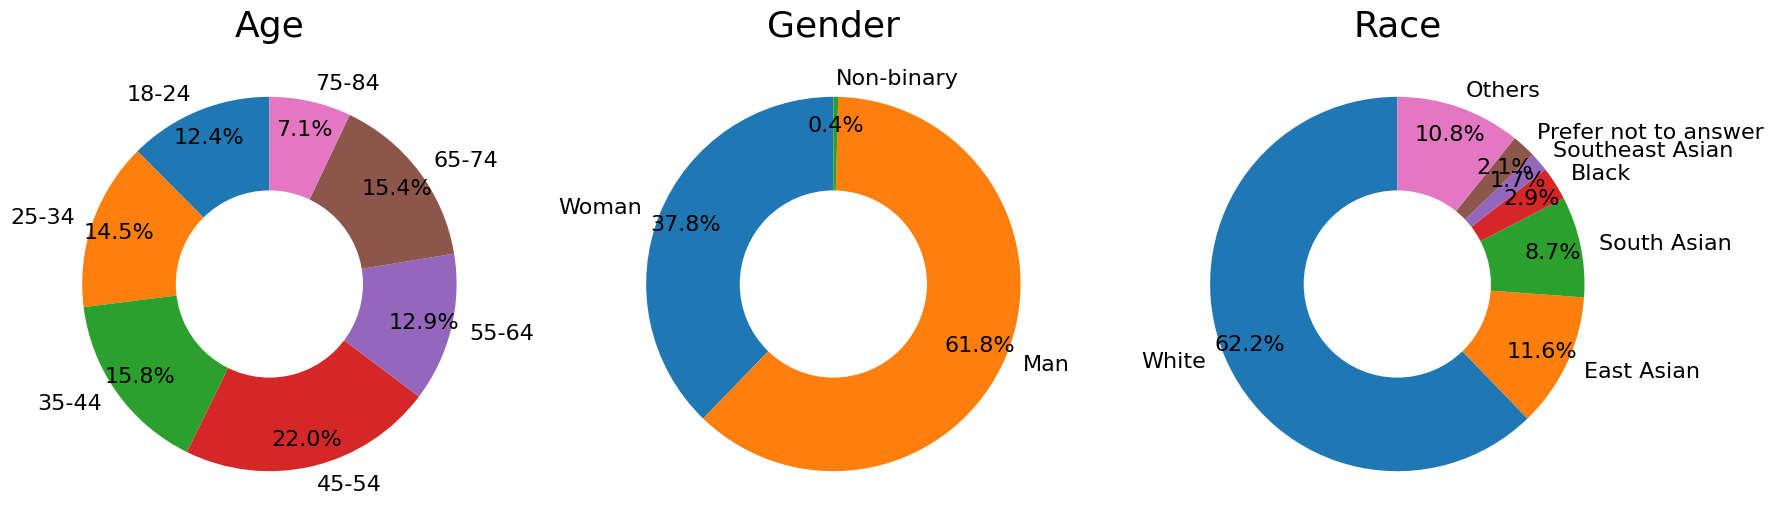

In [309]:
age_groups = ['18-24', '25-34', '35-44', '45-54', '55-64', '65-74', '75-84']
age_counts = [30, 35, 38, 53, 31, 37, 17]
age_percentage = [age/sum(age_counts) for age in age_counts]
gender_groups = ['Woman', 'Man', 'Non-binary']
gender_counts = [91, 149, 1]
gender_percentage = [gender/sum(gender_counts) for gender in gender_counts]
race_groups = ['White', 'East Asian', 'South Asian', 'Black', 'Southeast Asian', 'Prefer not to answer', 'Others']
race_counts = [150, 28, 21, 7, 4, 5, 26]
race_percentage = [race/sum(race_counts) for race in race_counts]
# 1. Define distinct demographic categories and values
demographics = {
    'Age': {
        'labels': age_groups,
        'sizes': age_percentage,
    },
    'Gender': {
        'labels': gender_groups,
        'sizes': gender_percentage,
    },
    'Race': {
        'labels': race_groups,
        'sizes': race_percentage,
    }
}

# create subplots
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

# Iterate through demographics and plot
for i, (metric, content) in enumerate(demographics.items()):
    axs[i].pie(
        content['sizes'],
        labels=content['labels'],
        autopct='%1.1f%%',
        startangle=90,
        textprops={'fontsize': 16},
        pctdistance=0.85  # Moves percentage labels inside cleanly
    )

    centre_circle = plt.Circle((0,0), 0.50, fc='white')
    axs[i].add_artist(centre_circle)
    axs[i].set_title(metric, fontsize=26, pad=10)

# 4. Clean up spacing and render
plt.tight_layout()
plt.show()

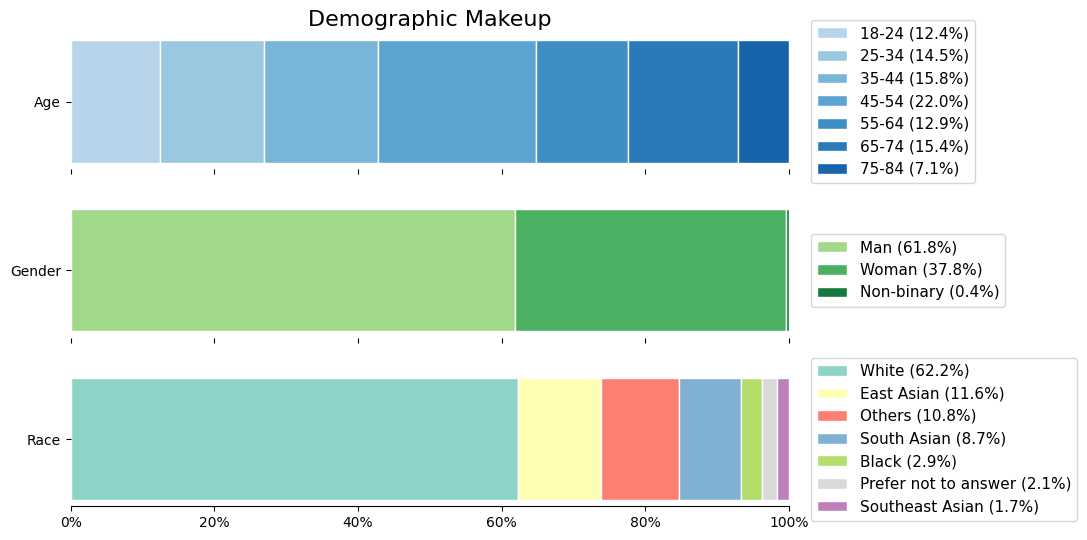

In [310]:
fig, axes = plt.subplots(3, 1, figsize=(11, 5.5), sharex=True)
categories = ['Age', 'Gender', 'Race']

for ax, cat in zip(axes, categories):
    labels = demographics_sorted[cat]['labels']
    sizes = demographics_sorted[cat]['sizes']

    left = 0
    # Apply visually distinct color palettes for each row
    if cat == 'Age':
        colors = plt.cm.Blues(np.linspace(0.3, 0.8, len(labels)))
    elif cat == 'Gender':
        colors = plt.cm.YlGn(np.linspace(0.4, 0.8, len(labels)))
    else:
        colors = plt.cm.Set3(np.linspace(0, 0.8, len(labels)))

    for label, size, color in zip(labels, sizes, colors):
        pct = size * 100
        ax.barh(cat, size, left=left, color=color, edgecolor='white', height=0.6, label=f"{label} ({pct:.1f}%)")
        left += size

    # Place legends to the right of each row to keep labels perfectly legible
    ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=11)
    ax.set_xlim(0, 1)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(cat == 'Race')
    ax.spines['left'].set_visible(False)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x*100)}%'))

axes[0].set_title('Demographic Makeup', fontsize=16)
plt.tight_layout()

## Respondent Background Knowledge

In [311]:
# AI Usage

mapped_df[['HGROUP','WORK','STUDY','ADVICE','CONTENT','OTHERS']].groupby('HGROUP').describe()

WORK                                              STUDY            \
          count      mean       std  min  25%  50%  75%  max count      mean   
HGROUP                                                                         
CONTROL    91.0  2.241758  1.493249  0.0  1.0  2.0  3.5  5.0  91.0  2.362637   
CONTROL_G  29.0  2.482759  1.478916  1.0  1.0  3.0  3.0  5.0  29.0  2.620690   
TREATMENT  91.0  2.681319  1.459674  1.0  1.0  3.0  4.0  5.0  91.0  2.626374   
VIDEO      30.0  2.133333  1.166585  1.0  1.0  2.0  3.0  5.0  30.0  2.200000   

           ... CONTENT      OTHERS                                          \
           ...     75%  max  count      mean       std  min  25%  50%  75%   
HGROUP     ...                                                               
CONTROL    ...     4.0  5.0   91.0  2.153846  1.429243  0.0  1.0  2.0  3.0   
CONTROL_G  ...     5.0  5.0   29.0  2.068966  1.533694  0.0  1.0  1.0  3.0   
TREATMENT  ...     3.5  5.0   91.0  2.065934  1.451453  0.0  1.0  2.0  3.0   
VIDEO      ...     3.0  4.0   30.0  1.333333  1.372974  0.0  1.0  1.0  1.0   

                
           max  
HGROUP          
CONTROL    5.0  
CONTROL_G  5.0  
TREATMENT  5.0  
VIDEO      5.0  

[4 rows x 40 columns]

In [312]:
knowledge_df = pd.DataFrame({
    "knowledge": [
        "Technical","Technical",
        "Social and Ethical","Social and Ethical"
    ] * 4,

    "group": (
        ["$G_{T/E/H}$"]*4 +
        ["$I_{T/E/H}$"]*4 +
        ["$I_G$"]*4 +
        ["$V$"]*4
    ),

    "time": ["Pre","Post"] * 8,

    "score": [
        # treatment
        mapped_df.loc[mapped_df['HGROUP']=='TREATMENT']['PRE_K1'].mean(), #pre_k1 mean
        mapped_df.loc[mapped_df['HGROUP']=='TREATMENT']['POST_K1'].mean(), #post_k1 mean
        mapped_df.loc[mapped_df['HGROUP']=='TREATMENT']['PRE_K2'].mean(), #pre_k2 mean
        mapped_df.loc[mapped_df['HGROUP']=='TREATMENT']['POST_K2'].mean(), #pre_k2 mean
        # control
        mapped_df.loc[mapped_df['HGROUP']=='CONTROL']['PRE_K1'].mean(), #pre_k1 mean
        mapped_df.loc[mapped_df['HGROUP']=='CONTROL']['POST_K1'].mean(), #post_k1 mean
        mapped_df.loc[mapped_df['HGROUP']=='CONTROL']['PRE_K2'].mean(), #pre_k2 mean
        mapped_df.loc[mapped_df['HGROUP']=='CONTROL']['POST_K2'].mean(), #pre_k2 mean
        # control_g
        mapped_df.loc[mapped_df['HGROUP']=='CONTROL_G']['PRE_K1'].mean(), #pre_k1 mean
        mapped_df.loc[mapped_df['HGROUP']=='CONTROL_G']['POST_K1'].mean(), #post_k1 mean
        mapped_df.loc[mapped_df['HGROUP']=='CONTROL_G']['PRE_K2'].mean(), #pre_k2 mean
        mapped_df.loc[mapped_df['HGROUP']=='CONTROL_G']['POST_K2'].mean(), #pre_k2 mean
        # video
        mapped_df.loc[mapped_df['HGROUP']=='VIDEO']['PRE_K1'].mean(), #pre_k1 mean
        mapped_df.loc[mapped_df['HGROUP']=='VIDEO']['POST_K1'].mean(), #post_k1 mean
        mapped_df.loc[mapped_df['HGROUP']=='VIDEO']['PRE_K2'].mean(), #pre_k2 mean
        mapped_df.loc[mapped_df['HGROUP']=='VIDEO']['POST_K2'].mean(), #pre_k2 mean
        ]
})

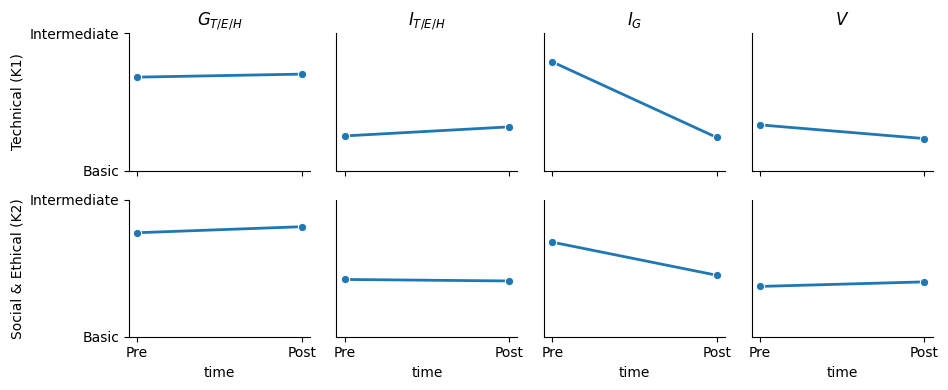

In [313]:
g = sns.relplot(
    data=knowledge_df,
    x="time",
    y="score",
    kind="line",
    row="knowledge",
    col="group",
    marker="o",
    linewidth=2,
    height=2,
    aspect=1.2,
    facet_kws=dict(sharey=False)
)

titles = [
    ['$G_{T/E/H}$', '$I_{T/E/H}$', '$I_G$', '$V$'],
    ['', '', '', '']
]

for ax, title in zip(g.axes.flat, sum(titles, [])):
    ax.set_title(title)

# set ticks
for row in g.axes:
    # Leftmost subplot
    row[0].set_yticks([2, 3])
    row[0].set_yticklabels(["Basic", "Intermediate"])
    # Remaining subplots
    for ax in row[1:]:
        ax.set_yticks([2, 3])
        ax.set_yticklabels([])
        ax.tick_params(axis="y", left=False)

g.axes[0, 0].set_ylabel("Technical (K1)")
g.axes[1, 0].set_ylabel("Social & Ethical (K2)")

plt.tight_layout()
plt.show()

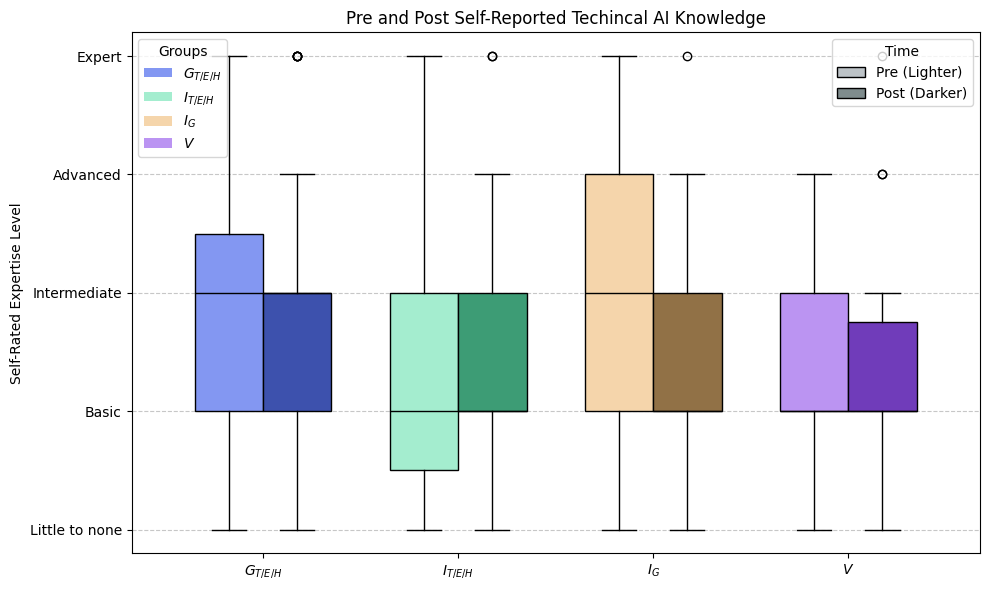

In [314]:
groups = ['$G_{T/E/H}$','$I_{T/E/H}$', '$I_G$', '$V$']
score_scale = [1,2,3,4,5]
score_labels = ['Little to none', 'Basic', 'Intermediate',
                'Advanced','Expert'] #from answer map

pre_k1 = [mapped_df.loc[mapped_df['HGROUP']=='TREATMENT']['PRE_K1'],
          mapped_df.loc[mapped_df['HGROUP']=='CONTROL']['PRE_K1'],
          mapped_df.loc[mapped_df['HGROUP']=='CONTROL_G']['PRE_K1'],
          mapped_df.loc[mapped_df['HGROUP']=='VIDEO']['PRE_K1']]
post_k1 = [mapped_df.loc[mapped_df['HGROUP']=='TREATMENT']['POST_K1'],
          mapped_df.loc[mapped_df['HGROUP']=='CONTROL']['POST_K1'],
          mapped_df.loc[mapped_df['HGROUP']=='CONTROL_G']['POST_K1'],
          mapped_df.loc[mapped_df['HGROUP']=='VIDEO']['POST_K1']]

# 2. Configure positions and spacing
positions = np.arange(1, 5)  # Centers: 1, 2, 3, 4
width = 0.35                 # Width of each box

# 3. Define unique color pairs for each group (Lighter for Pre, Darker for Post)
colors_pre = ['#8397f2', '#a4edcf', '#f5d5ab', '#bb94f2']   # Blue, Green, Red, Purple
colors_post = ['#3d51ad', '#3d9c75', '#917146', '#703cba']  # Darker versions

fig, ax = plt.subplots(figsize=(10, 6))

# 4. Plot Pre and Post boxes with an offset
bp_pre = ax.boxplot(pre_k1, positions=positions - width/2, widths=width, patch_artist=True)
bp_post = ax.boxplot(post_k1, positions=positions + width/2, widths=width, patch_artist=True)

# 5. Apply colors to the boxes and style medians
for i in range(4):
    bp_pre['boxes'][i].set_facecolor(colors_pre[i])
    bp_post['boxes'][i].set_facecolor(colors_post[i])

    # Change median lines to black for visibility
    bp_pre['medians'][i].set_color('black')
    bp_post['medians'][i].set_color('black')

# Set plot titles and labels
ax.set_xticks(positions)
ax.set_xticklabels(groups)
ax.set_ylabel('Self-Rated Expertise Level')
ax.set_yticks(score_scale)
ax.set_yticklabels(score_labels)
ax.set_title('Pre and Post Self-Reported Techincal AI Knowledge')
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Legends
group_legends = [Patch(facecolor=colors_pre[i], label=groups[i]) for i in range(4)]
legend1 = ax.legend(handles=group_legends, loc='upper left', title="Groups")
time_legends = [
    Patch(facecolor='#bdc3c7', edgecolor='black', label='Pre (Lighter)'),
    Patch(facecolor='#7f8c8d', edgecolor='black', label='Post (Darker)')
]
ax.add_artist(legend1) # Keep the first legend active
ax.legend(handles=time_legends, loc='upper right', title="Time")

plt.tight_layout()
plt.show()

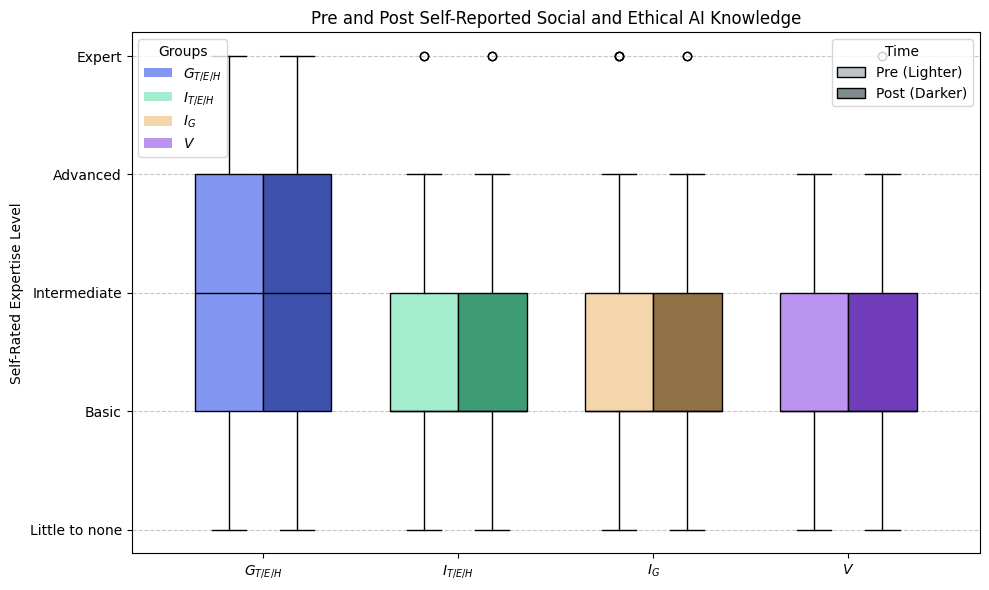

In [315]:
groups = ['$G_{T/E/H}$','$I_{T/E/H}$', '$I_G$', '$V$']
score_scale = [1,2,3,4,5]
score_labels = ['Little to none', 'Basic', 'Intermediate',
                'Advanced','Expert'] #from answer map

pre_k2 = [mapped_df.loc[mapped_df['HGROUP']=='TREATMENT']['PRE_K2'],
          mapped_df.loc[mapped_df['HGROUP']=='CONTROL']['PRE_K2'],
          mapped_df.loc[mapped_df['HGROUP']=='CONTROL_G']['PRE_K2'],
          mapped_df.loc[mapped_df['HGROUP']=='VIDEO']['PRE_K2']]
post_k2 = [mapped_df.loc[mapped_df['HGROUP']=='TREATMENT']['POST_K2'],
          mapped_df.loc[mapped_df['HGROUP']=='CONTROL']['POST_K2'],
          mapped_df.loc[mapped_df['HGROUP']=='CONTROL_G']['POST_K2'],
          mapped_df.loc[mapped_df['HGROUP']=='VIDEO']['POST_K2']]

# 2. Configure positions and spacing
positions = np.arange(1, 5)  # Centers: 1, 2, 3, 4
width = 0.35                 # Width of each box

# 3. Define unique color pairs for each group (Lighter for Pre, Darker for Post)
colors_pre = ['#8397f2', '#a4edcf', '#f5d5ab', '#bb94f2']   # Blue, Green, Red, Purple
colors_post = ['#3d51ad', '#3d9c75', '#917146', '#703cba']  # Darker versions

fig, ax = plt.subplots(figsize=(10, 6))

# 4. Plot Pre and Post boxes with an offset
bp_pre = ax.boxplot(pre_k2, positions=positions - width/2, widths=width, patch_artist=True)
bp_post = ax.boxplot(post_k2, positions=positions + width/2, widths=width, patch_artist=True)

# 5. Apply colors to the boxes and style medians
for i in range(4):
    bp_pre['boxes'][i].set_facecolor(colors_pre[i])
    bp_post['boxes'][i].set_facecolor(colors_post[i])

    # Change median lines to black for visibility
    bp_pre['medians'][i].set_color('black')
    bp_post['medians'][i].set_color('black')

# Set plot titles and labels
ax.set_xticks(positions)
ax.set_xticklabels(groups)
ax.set_ylabel('Self-Rated Expertise Level')
ax.set_yticks(score_scale)
ax.set_yticklabels(score_labels)
ax.set_title('Pre and Post Self-Reported Social and Ethical AI Knowledge')
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Legends
group_legends = [Patch(facecolor=colors_pre[i], label=groups[i]) for i in range(4)]
legend1 = ax.legend(handles=group_legends, loc='upper left', title="Groups")
time_legends = [
    Patch(facecolor='#bdc3c7', edgecolor='black', label='Pre (Lighter)'),
    Patch(facecolor='#7f8c8d', edgecolor='black', label='Post (Darker)')
]
ax.add_artist(legend1) # Keep the first legend active
ax.legend(handles=time_legends, loc='upper right', title="Time")

plt.tight_layout()
plt.show()

# Descriptives

- Pre and Post means of each composite
- Visualization of above

In [316]:
# means
print("Motivation")
print(mean_composite_df[['HGROUP','PRE_M']].groupby('HGROUP').describe().round(3))
print(mean_composite_df[['HGROUP','POST_M']].groupby('HGROUP').describe().round(3))
print("\nConcern")
print(mean_composite_df[['HGROUP','PRE_C']].groupby('HGROUP').describe().round(3))
print(mean_composite_df[['HGROUP','POST_C']].groupby('HGROUP').describe().round(3))
print("\nHarms (Shared) (H)")
print(mean_composite_df[['HGROUP','PRE_H_SHARED']].groupby('HGROUP').describe().round(3))
print(mean_composite_df[['HGROUP','POST_H_SHARED']].groupby('HGROUP').describe().round(3))
print("\nHarms (Relevant) (H*)")
print(mean_composite_df[['HGROUP','PRE_H_REL']].groupby('HGROUP').describe().round(3))
print(mean_composite_df[['HGROUP','POST_H_REL']].groupby('HGROUP').describe().round(3))

Motivation
          PRE_M                                           
          count   mean    std  min    25%    50%  75%  max
HGROUP                                                    
CONTROL    91.0  3.553  0.942  1.0  3.000  3.667  4.0  5.0
CONTROL_G  29.0  3.448  0.977  1.0  3.000  3.333  4.0  5.0
TREATMENT  91.0  3.399  1.099  1.0  2.833  3.667  4.0  5.0
VIDEO      30.0  3.378  1.130  1.0  3.000  3.667  4.0  5.0
          POST_M                                         
           count   mean    std  min  25%    50%  75%  max
HGROUP                                                   
CONTROL     91.0  3.645  0.870  1.0  3.0  4.000  4.0  5.0
CONTROL_G   29.0  3.563  0.984  1.0  3.0  3.667  4.0  5.0
TREATMENT   91.0  3.626  1.034  1.0  3.0  4.000  4.0  5.0
VIDEO       30.0  3.467  1.088  1.0  3.0  4.000  4.0  5.0

Concern
          PRE_C                                       
          count   mean    std  min  25%  50%  75%  max
HGROUP                                             

In [317]:
mean_composite_df[['HGROUP','C_CHANGE']].groupby('HGROUP').describe()

C_CHANGE                                              
             count      mean       std  min  25%  50%   75%  max
HGROUP                                                          
CONTROL       91.0  0.140659  0.700155 -3.0 -0.2  0.0  0.50  1.6
CONTROL_G     29.0  0.206897  0.758726 -1.4 -0.2  0.0  0.60  2.4
TREATMENT     91.0  0.323077  0.785292 -1.6  0.0  0.0  0.60  4.6
VIDEO         30.0 -0.040000  0.502133 -1.4 -0.2  0.0  0.15  1.0

# Summary of Change

bar plot to show mean change across motivation, concern, harms correctness

/tmp/ipykernel_3959/2096771948.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_yticklabels(df['Group'],fontsize=14)
/tmp/ipykernel_3959/2096771948.py:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[2].set_yticklabels(df['Group'],fontsize=14)


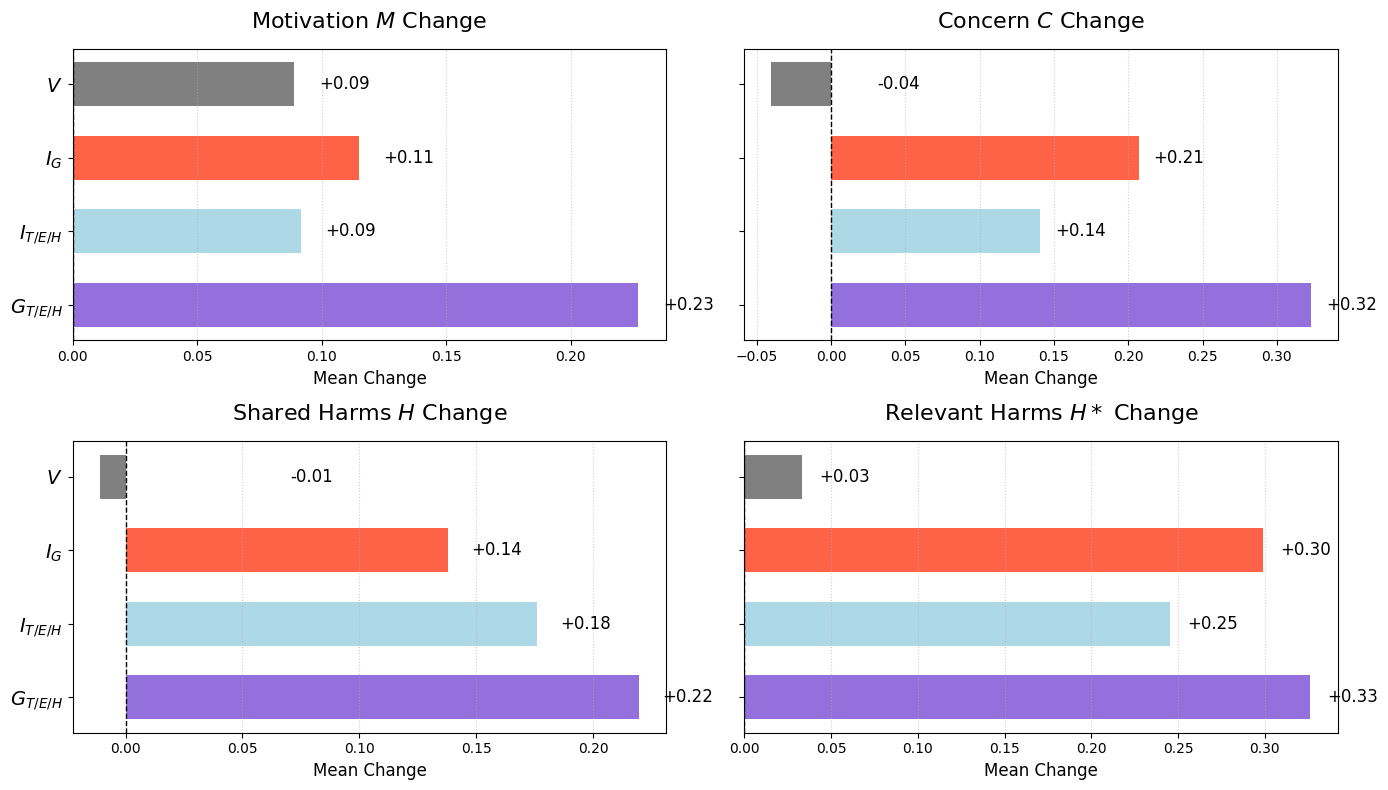

In [318]:
# Create df with mean change for each treatment group
change_summary = {
    "Titles": ["Motivation $M$ Change"] * 4 + ["Concern $C$ Change"] * 4 + ["Shared Harms $H$ Change"] * 4 + ["Relevant Harms $H*$ Change"] * 4,
    "Group": ['$G_{T/E/H}$', '$I_{T/E/H}$', '$I_G$', '$V$'] * 4,
    # order:        []
    "Change_Score": [0.227106, 0.091575, 0.114943, 0.088889,
                     0.323077, 0.140659, 0.206897, -0.040000,
                     0.219780, 0.175824, 0.137931, -0.011111,
                     0.326007, 0.245421, 0.298851, 0.033333]
}
df = pd.DataFrame(change_summary)

# Create subplots and flatten for iteration
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 8), sharey=True)
axes = axes.flatten()

# Color palette for each treatment groups
colors = ['mediumpurple', 'lightblue', 'tomato', 'grey']

# Loop through each subplots
subplots_list = df["Titles"].unique()
for i, subplot_name in enumerate(subplots_list):
    ax = axes[i]

    # get data for the subplot
    sub_df = df[df["Titles"] == subplot_name]

    # plot bars
    bars = ax.barh(sub_df["Group"], sub_df["Change_Score"], color=colors, height=0.6)

    # add line at x=0
    ax.axvline(0, color='black', linewidth=1, linestyle='--')

    # Styling and formatting
    ax.set_title(f"{subplot_name}", fontsize=16, pad=15)
    ax.set_xlabel("Mean Change", fontsize=12)
    ax.grid(axis='x', linestyle=':', alpha=0.6)

    # Add mean to end of bars
    for bar in bars:
        width = bar.get_width()
        ha_alignment = 'left' if width >= 0 else 'right'
        offset = 0.01 if width >= 0 else 0.1
        ax.text(width + offset, bar.get_y() + bar.get_height()/2, f'{width:+.2f}',
                va='center', ha=ha_alignment, fontsize=12,)

axes[0].set_yticklabels(df['Group'],fontsize=14)
axes[2].set_yticklabels(df['Group'],fontsize=14)

plt.tight_layout()
plt.show()

## Learning Commitment

In [319]:
commitment_map = {
    'I am already learning AI': int(1),
    'I am not interested in learning AI': int(0),
    'I have learned AI and know enough': int(1),
    'within the next few months': int(3),
    'within the year': int(2),
    'within this month': int(4),
    'within this week': int(5)
}
mapped_df = mapped_df.replace(commitment_map)

/tmp/ipykernel_3959/2046699265.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  mapped_df = mapped_df.replace(commitment_map)


In [320]:
commitment_data = {
    'Treatments': ['$G_{T/E/H}$', '$I_{T/E/H}$', '$I_G$', '$V$'],
    'Not interested': [0 for i in range(4)],
    'Already learning/know enough': [0 for i in range(4)],
    'Within the week': [0 for i in range(4)],
    'Within the month': [0 for i in range(4)],
    'Within few months': [0 for i in range(4)],
    'Within the year': [0 for i in range(4)]
}

In [321]:
hgroups = ['TREATMENT', 'CONTROL', 'CONTROL_G', 'VIDEO']
hgroup_count = [0 for i in range(4)]
for i in range(4):
  commits = mapped_df.loc[mapped_df['HGROUP']==hgroups[i]]['COMMITMENT']
  for c in commits:
    hgroup_count[i] += 1
    if c==0:
      commitment_data['Not interested'][i]+=1
    elif c==1:
      commitment_data['Already learning/know enough'][i]+=1
    elif c <= 2:
      commitment_data['Within the year'][i] += 1
    elif c <= 3:
      commitment_data['Within the year'][i] += 1
      commitment_data['Within few months'][i] += 1
    elif c <= 4:
      commitment_data['Within the year'][i] += 1
      commitment_data['Within few months'][i] += 1
      commitment_data['Within the month'][i] += 1
    elif c <= 5:
      commitment_data['Within the year'][i] += 1
      commitment_data['Within few months'][i] += 1
      commitment_data['Within the month'][i] += 1
      commitment_data['Within the week'][i] += 1
commitment_data['Not interested']=np.array(commitment_data['Not interested'])/np.array(hgroup_count)*100
commitment_data['Already learning/know enough']=np.array(commitment_data['Already learning/know enough'])/np.array(hgroup_count)*100
commitment_data['Within the year']=np.array(commitment_data['Within the year'])/np.array(hgroup_count)*100
commitment_data['Within few months']=np.array(commitment_data['Within few months'])/np.array(hgroup_count)*100
commitment_data['Within the month']=np.array(commitment_data['Within the month'])/np.array(hgroup_count)*100
commitment_data['Within the week']=np.array(commitment_data['Within the week'])/np.array(hgroup_count)*100

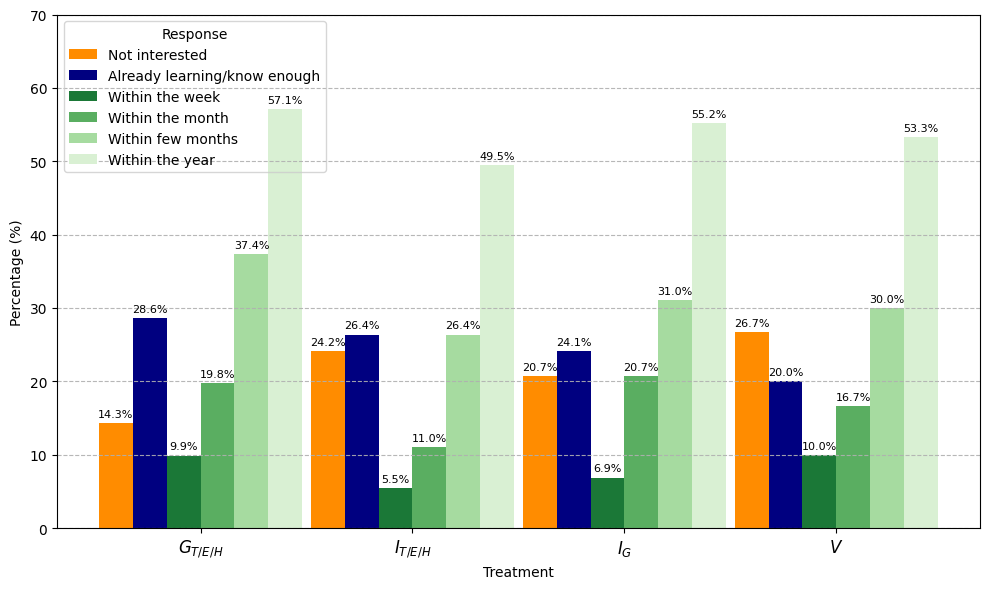

In [322]:
treatments = commitment_data['Treatments']
categories = list(commitment_data.keys())[1:]

x = np.arange(len(treatments))
width = 0.16

fig, ax = plt.subplots(figsize=(10, 6))

colors = [
    "#FF8C00",  # black
    "#000080",  # blue
    "#1B7837",  # dark green
    "#5AAE61",  # medium green
    "#A6DBA0",  # light green
    "#D9F0D3",  # very light green
]

for i, category in enumerate(categories):
    bars = ax.bar(
        x + (i - (len(categories)-1)/2) * width,
        commitment_data[category],
        width,
        label=category,
        color=colors[i],
        edgecolor="black",
        linewidth=0
    )

    ax.bar_label(
        bars,
        labels=[f"{v:.1f}%" for v in commitment_data[category]],
        padding=3,
        fontsize=8,
        rotation=0  # optional if labels overlap
    )

ax.set_xticks(x)
ax.set_xticklabels(treatments, fontsize=12)
ax.set_ylabel('Percentage (%)')
ax.set_xlabel('Treatment')
ax.set_ylim(0, 70)

ax.legend(title='Response', facecolor='none',)
ax.grid(axis='y', linestyle='--', alpha=0.9)

plt.tight_layout()
plt.show()

# Between Group Analysis

ANCOVA for change of motivation, concern and harms knowledge. Model: Post∼Pre+Group

*   Game vs Narrative-based Infographic
*   Game vs Harms-baed Infographic
*   Game vs Video



## Omnibus ANCOVA

In [323]:
M_model = smf.ols(
    "POST_M ~ PRE_M + C(HGROUP)",
    data=mean_composite_df
).fit()

C_model = smf.ols(
    "POST_C ~ PRE_C + C(HGROUP)",
    data=mean_composite_df
).fit()

H_model = smf.ols(
    "POST_H_SHARED ~ PRE_H_SHARED + C(HGROUP)",
    data=mean_composite_df
).fit()

Hstar_model = smf.ols(
    "POST_H_REL ~ PRE_H_REL + C(HGROUP)",
    data=mean_composite_df
).fit()

ancova_table = sm.stats.anova_lm(M_model, typ=2)
ancova_table['eta_p^2'] = ancova_table['sum_sq'] / (ancova_table['sum_sq'] + ancova_table.loc['Residual', 'sum_sq'])
print("Motivation ANCOVA Table:")
print(ancova_table.round(3))

ancova_table = sm.stats.anova_lm(C_model, typ=2)
ancova_table['eta_p^2'] = ancova_table['sum_sq'] / (ancova_table['sum_sq'] + ancova_table.loc['Residual', 'sum_sq'])
print("\nConcern ANCOVA Table:")
print(ancova_table.round(3))

ancova_table = sm.stats.anova_lm(H_model, typ=2)
ancova_table['eta_p^2'] = ancova_table['sum_sq'] / (ancova_table['sum_sq'] + ancova_table.loc['Residual', 'sum_sq'])
print("\nShared Harms (H) ANCOVA Table:")
print(ancova_table.round(3))

ancova_table = sm.stats.anova_lm(Hstar_model, typ=2)
ancova_table['eta_p^2'] = ancova_table['sum_sq'] / (ancova_table['sum_sq'] + ancova_table.loc['Residual', 'sum_sq'])
print("\nRel Harms (H*) ANCOVA Table:")
print(ancova_table.round(3))

Motivation ANCOVA Table:
            sum_sq     df        F  PR(>F)  eta_p^2
C(HGROUP)    0.763    3.0    1.066   0.364    0.013
PRE_M      169.570    1.0  711.018   0.000    0.751
Residual    56.283  236.0      NaN     NaN    0.500

Concern ANCOVA Table:
            sum_sq     df        F  PR(>F)  eta_p^2
C(HGROUP)    1.883    3.0    1.434   0.234    0.018
PRE_C      109.968    1.0  251.211   0.000    0.516
Residual   103.309  236.0      NaN     NaN    0.500

Shared Harms (H) ANCOVA Table:
               sum_sq     df        F  PR(>F)  eta_p^2
C(HGROUP)       0.819    3.0    0.529   0.663    0.007
PRE_H_SHARED  214.716    1.0  415.861   0.000    0.638
Residual      121.851  236.0      NaN     NaN    0.500

Rel Harms (H*) ANCOVA Table:
            sum_sq     df        F  PR(>F)  eta_p^2
C(HGROUP)    2.336    3.0    1.112   0.345    0.014
PRE_H_REL  158.716    1.0  226.765   0.000    0.490
Residual   165.180  236.0      NaN     NaN    0.500


## Planned Contrasts

In [324]:
ordered_mapped_df = mean_composite_df.copy()
groups = ["TREATMENT", "CONTROL", "CONTROL_G", "VIDEO"]
ordered_mapped_df['HGROUP'] = pd.Categorical(ordered_mapped_df['HGROUP'], categories=groups, ordered=True)

In [325]:
M_model = smf.ols("POST_M ~ PRE_M + C(HGROUP) - 1", data=mean_composite_df).fit()
C_model = smf.ols("POST_C ~ PRE_C + C(HGROUP) - 1", data=mean_composite_df).fit()
H_model = smf.ols("POST_H_SHARED ~ PRE_H_SHARED + C(HGROUP) - 1", data=mean_composite_df).fit()
Hstar_model = smf.ols("POST_H_REL ~ PRE_H_REL + C(HGROUP) - 1", data=mean_composite_df).fit()

contrasts = {
    "TREATMENT vs CONTROL": "C(HGROUP)[TREATMENT] - C(HGROUP)[CONTROL]",
    "TREATMENT vs CONTROL_G": "C(HGROUP)[TREATMENT] - C(HGROUP)[CONTROL_G]",
    "TREATMENT vs VIDEO": "C(HGROUP)[TREATMENT] - C(HGROUP)[VIDEO]",
}

print("Motivation Planned Contrasts")
for title, hypothesis_string in contrasts.items():
    t_test = M_model.t_test(hypothesis_string)

    print(f"{title}:")
    print(t_test)
    #print(f"  t-statistic = {t_test.tvalue[0][0]:.3f}")
    #print(f"  p-value     = {t_test.pvalue:.4f}")

print("\nConcern Planned Contrasts")
for title, hypothesis_string in contrasts.items():
    t_test = C_model.t_test(hypothesis_string)

    print(f"{title}:")
    print(t_test)

print("\nHarms Shared Planned Contrasts")
for title, hypothesis_string in contrasts.items():
    t_test = H_model.t_test(hypothesis_string)

    print(f"{title}:")
    print(t_test)

print("\nHarms Rel Planned Contrasts")
for title, hypothesis_string in contrasts.items():
    t_test = Hstar_model.t_test(hypothesis_string)

    print(f"{title}:")
    print(t_test)

Motivation Planned Contrasts
TREATMENT vs CONTROL:
                             Test for Constraints                             
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
c0             0.1078      0.073      1.486      0.139      -0.035       0.251
TREATMENT vs CONTROL_G:
                             Test for Constraints                             
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
c0             0.1033      0.104      0.992      0.322      -0.102       0.309
TREATMENT vs VIDEO:
                             Test for Constraints                             
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
c0             0.1421      0.103    

# Media Satisfaction

## Reliability & Descriptives

In [326]:
# Reliability

print("Cronbach's Alphas")
print("POST:")
print("All:")
print(pg.cronbach_alpha(data = satisfaction_df))
print("Game:")
print(pg.cronbach_alpha(data = satisfaction_df_game_only.loc[satisfaction_df_game_only['HGROUP']=='TREATMENT'][['V3','V4']]))

satisfaction_df = mapped_df[['V1', 'V2']]
satisfaction_df_game_only = mapped_df[['V3', 'V4','HGROUP']]

Cronbach's Alphas
POST:
All:
(np.float64(0.8716234467855208), array([0.835, 0.9  ]))
Game:
(np.float64(0.8119992878760904), array([0.715, 0.876]))


In [333]:
# repeat for other Vis with i from 1 to 5
mapped_df[['V5', 'HGROUP']].groupby('HGROUP').describe()

V5                                             
          count      mean       std  min  25%  50%  75%  max
HGROUP                                                      
CONTROL    91.0  2.736264  1.272226  1.0  2.0  3.0  4.0  5.0
CONTROL_G  29.0  2.965517  1.179672  1.0  2.0  3.0  4.0  5.0
TREATMENT  91.0  2.274725  1.085930  1.0  1.0  2.0  3.0  5.0
VIDEO      30.0  2.133333  1.136642  1.0  1.0  2.0  3.0  5.0

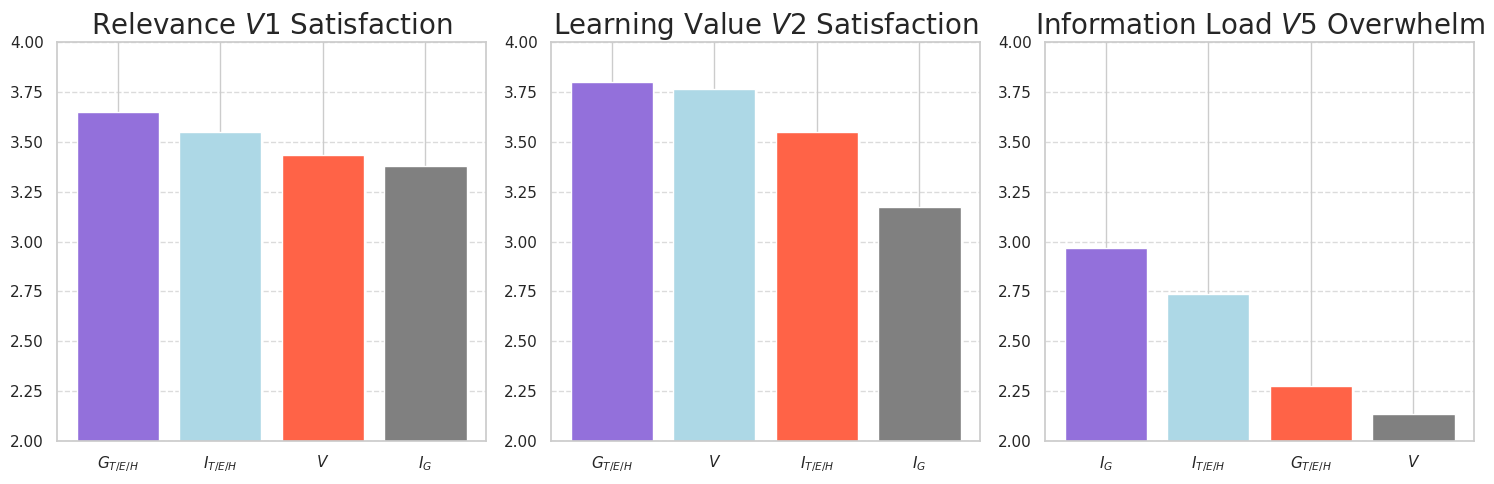

In [350]:
change_summary = {
    "Titles": ['Relevance $V1$ Satisfaction'] * 4 + ["Learning Value $V2$ Satisfaction"] * 4 + ["Information Load $V5$ Overwhelm"] * 4,
    "Group": ['$G_{T/E/H}$', '$I_{T/E/H}$', '$I_G$', '$V$'] * 3,
    "Score": [3.648352, 3.549451, 3.379310, 3.433333,
                     3.802198, 3.549451, 3.172414, 3.766667,
                     2.274725, 2.736264, 2.965517, 2.133333,]
}

df = pd.DataFrame(change_summary)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

colors = ['mediumpurple', 'lightblue', 'tomato', 'grey']

# loop through titles
titles = df['Titles'].unique()
for i, title in enumerate(titles):
    ax = axes[i]

    sub_df = df[df['Titles'] == title].sort_values(by='Score', ascending=False)

    ax.bar(sub_df['Group'], sub_df['Score'], color=colors[:len(sub_df)])

    ax.set_axisbelow(True)
    ax.yaxis.grid(True, linestyle='--', alpha=0.7)

    ax.set_title(title, fontsize=20)
    #ax.set_xlabel('Treatment Group', fontsize=11)
    #ax.set_ylabel('Mean Change Score', fontsize=11)
    ax.set_ylim(2.0, 4)

plt.tight_layout()
plt.show()

## Statistical Significance between group

In [327]:
for x in ['V1', 'V2', 'V3', 'V4', 'V5']:
  mean_composite_df[x] = mapped_df[x]

In [329]:
# repeat for motivation, concern and shared harms
# by replacing H_REL_CHANGE with M_CHANGE, C_CHANGE, H_SHARED_CHANGE
model = smf.ols(
    "H_REL_CHANGE ~ V1 + V2 + V5",
    data=mean_composite_df
).fit()

print(model_M.summary())

                            OLS Regression Results                            
Dep. Variable:           H_REL_CHANGE   R-squared:                       0.034
Model:                            OLS   Adj. R-squared:                  0.022
Method:                 Least Squares   F-statistic:                     2.792
Date:                Mon, 06 Jul 2026   Prob (F-statistic):             0.0412
Time:                        11:51:57   Log-Likelihood:                -307.78
No. Observations:                 241   AIC:                             623.6
Df Residuals:                     237   BIC:                             637.5
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.4825      0.277     -1.744      0.0

# Extras

## Storylines

In [230]:
M_model = smf.ols(
    "POST_M ~ PRE_M + C(HARM_GROUP)",
    data=mean_composite_df
).fit()

C_model = smf.ols(
    "POST_C ~ PRE_C + C(HARM_GROUP)",
    data=mean_composite_df
).fit()

H_model = smf.ols(
    "POST_H_SHARED ~ PRE_H_SHARED + C(HARM_GROUP)",
    data=mean_composite_df
).fit()

Hstar_model = smf.ols(
    "POST_H_REL ~ PRE_H_REL + C(HARM_GROUP)",
    data=mean_composite_df
).fit()

ancova_table = sm.stats.anova_lm(M_model, typ=2)
ancova_table['eta_p^2'] = ancova_table['sum_sq'] / (ancova_table['sum_sq'] + ancova_table.loc['Residual', 'sum_sq'])
print("Motivation ANCOVA Table:")
print(ancova_table.round(3))

ancova_table = sm.stats.anova_lm(C_model, typ=2)
ancova_table['eta_p^2'] = ancova_table['sum_sq'] / (ancova_table['sum_sq'] + ancova_table.loc['Residual', 'sum_sq'])
print("\nConcern ANCOVA Table:")
print(ancova_table.round(3))

ancova_table = sm.stats.anova_lm(H_model, typ=2)
ancova_table['eta_p^2'] = ancova_table['sum_sq'] / (ancova_table['sum_sq'] + ancova_table.loc['Residual', 'sum_sq'])
print("\nShared Harms (H) ANCOVA Table:")
print(ancova_table.round(3))

ancova_table = sm.stats.anova_lm(Hstar_model, typ=2)
ancova_table['eta_p^2'] = ancova_table['sum_sq'] / (ancova_table['sum_sq'] + ancova_table.loc['Residual', 'sum_sq'])
print("\nRel Harms (H*) ANCOVA Table:")
print(ancova_table.round(3))

Motivation ANCOVA Table:
                sum_sq     df        F  PR(>F)  eta_p^2
C(HARM_GROUP)    0.249    3.0    0.345   0.793    0.004
PRE_M          168.834    1.0  701.530   0.000    0.748
Residual        56.797  236.0      NaN     NaN    0.500

Concern ANCOVA Table:
                sum_sq     df        F  PR(>F)  eta_p^2
C(HARM_GROUP)    1.654    3.0    1.257    0.29    0.016
PRE_C          106.887    1.0  243.634    0.00    0.508
Residual       103.538  236.0      NaN     NaN    0.500

Shared Harms (H) ANCOVA Table:
                sum_sq     df        F  PR(>F)  eta_p^2
C(HARM_GROUP)    1.567    3.0    1.018   0.385    0.013
PRE_H_SHARED   213.022    1.0  415.128   0.000    0.638
Residual       121.103  236.0      NaN     NaN    0.500

Rel Harms (H*) ANCOVA Table:
                sum_sq     df        F  PR(>F)  eta_p^2
C(HARM_GROUP)    7.365    3.0    3.618   0.014    0.044
PRE_H_REL      151.902    1.0  223.844   0.000    0.487
Residual       160.151  236.0      NaN     NaN    

## Demographics

In [233]:
mean_composite_df['RACE'] = demo_df['RACE']
mean_composite_df['AGE'] = demo_df['AGE']
mean_composite_df['GENDER'] = demo_df['GENDER']

In [265]:
M_model = smf.ols(
    "POST_M ~ PRE_M + C(HGROUP) * C(AGE)",
    data=mean_composite_df
).fit()

C_model = smf.ols(
    "POST_C ~ PRE_C + C(HGROUP) * C(AGE)",
    data=mean_composite_df
).fit()

H_model = smf.ols(
    "POST_H_SHARED ~ PRE_H_SHARED + C(HGROUP) * C(AGE)",
    data=mean_composite_df
).fit()

Hstar_model = smf.ols(
    "POST_H_REL ~ PRE_H_REL + C(HGROUP) * C(AGE)",
    data=mean_composite_df
).fit()

ancova_table = sm.stats.anova_lm(M_model, typ=2)
ancova_table['eta_p^2'] = ancova_table['sum_sq'] / (ancova_table['sum_sq'] + ancova_table.loc['Residual', 'sum_sq'])
print("Motivation ANCOVA Table:")
print(ancova_table.round(3))

ancova_table = sm.stats.anova_lm(C_model, typ=2)
ancova_table['eta_p^2'] = ancova_table['sum_sq'] / (ancova_table['sum_sq'] + ancova_table.loc['Residual', 'sum_sq'])
print("\nConcern ANCOVA Table:")
print(ancova_table.round(3))

ancova_table = sm.stats.anova_lm(H_model, typ=2)
ancova_table['eta_p^2'] = ancova_table['sum_sq'] / (ancova_table['sum_sq'] + ancova_table.loc['Residual', 'sum_sq'])
print("\nShared Harms (H) ANCOVA Table:")
print(ancova_table.round(3))

ancova_table = sm.stats.anova_lm(Hstar_model, typ=2)
ancova_table['eta_p^2'] = ancova_table['sum_sq'] / (ancova_table['sum_sq'] + ancova_table.loc['Residual', 'sum_sq'])
print("\nRel Harms (H*) ANCOVA Table:")
print(ancova_table.round(3))

Motivation ANCOVA Table:
                   sum_sq     df        F  PR(>F)  eta_p^2
C(HGROUP)           1.172    3.0    1.591   0.206    0.022
C(AGE)              0.596    6.0    0.404   0.845    0.011
C(HGROUP):C(AGE)    3.491   18.0    0.790   0.704    0.063
PRE_M             139.052    1.0  566.013   0.000    0.727
Residual           52.327  213.0      NaN     NaN    0.500

Concern ANCOVA Table:
                  sum_sq     df        F  PR(>F)  eta_p^2
C(HGROUP)          2.164    3.0    1.669   0.191    0.023
C(AGE)             1.004    6.0    0.387   0.857    0.011
C(HGROUP):C(AGE)  10.989   18.0    1.412   0.132    0.107
PRE_C             98.247    1.0  227.309   0.000    0.516
Residual          92.062  213.0      NaN     NaN    0.500

Shared Harms (H) ANCOVA Table:
                   sum_sq     df        F  PR(>F)  eta_p^2
C(HGROUP)           1.286    3.0    0.839   0.433    0.012
C(AGE)              4.190    6.0    1.367   0.238    0.037
C(HGROUP):C(AGE)    9.425   18.0    1.025

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 3, but rank is 2
  warnings.warn('covariance of constraints does not have full '
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 6, but rank is 5
  warnings.warn('covariance of constraints does not have full '
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 18, but rank is 17
  warnings.warn('covariance of constraints does not have full '
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 3, but rank is 2
  warnings.warn('covariance of constraints does not have full '
/usr/local

In [266]:
M_model = smf.ols(
    "POST_M ~ PRE_M + C(HGROUP) * C(GENDER)",
    data=mean_composite_df
).fit()

C_model = smf.ols(
    "POST_C ~ PRE_C + C(HGROUP) * C(GENDER)",
    data=mean_composite_df
).fit()

H_model = smf.ols(
    "POST_H_SHARED ~ PRE_H_SHARED + C(HGROUP) * C(GENDER)",
    data=mean_composite_df
).fit()

Hstar_model = smf.ols(
    "POST_H_REL ~ PRE_H_REL + C(HGROUP) * C(GENDER)",
    data=mean_composite_df
).fit()

ancova_table = sm.stats.anova_lm(M_model, typ=2)
ancova_table['eta_p^2'] = ancova_table['sum_sq'] / (ancova_table['sum_sq'] + ancova_table.loc['Residual', 'sum_sq'])
print("Motivation ANCOVA Table:")
print(ancova_table.round(3))

ancova_table = sm.stats.anova_lm(C_model, typ=2)
ancova_table['eta_p^2'] = ancova_table['sum_sq'] / (ancova_table['sum_sq'] + ancova_table.loc['Residual', 'sum_sq'])
print("\nConcern ANCOVA Table:")
print(ancova_table.round(3))

ancova_table = sm.stats.anova_lm(H_model, typ=2)
ancova_table['eta_p^2'] = ancova_table['sum_sq'] / (ancova_table['sum_sq'] + ancova_table.loc['Residual', 'sum_sq'])
print("\nShared Harms (H) ANCOVA Table:")
print(ancova_table.round(3))

ancova_table = sm.stats.anova_lm(Hstar_model, typ=2)
ancova_table['eta_p^2'] = ancova_table['sum_sq'] / (ancova_table['sum_sq'] + ancova_table.loc['Residual', 'sum_sq'])
print("\nRel Harms (H*) ANCOVA Table:")
print(ancova_table.round(3))

Motivation ANCOVA Table:
                      sum_sq     df        F  PR(>F)  eta_p^2
C(HGROUP)              2.175    3.0    3.031   0.083    0.038
C(GENDER)              0.000    2.0    0.000   1.000    0.000
C(HGROUP):C(GENDER)    1.025    6.0    0.715   0.583    0.018
PRE_M                162.725    1.0  680.495   0.000    0.747
Residual              55.238  231.0      NaN     NaN    0.500

Concern ANCOVA Table:
                      sum_sq     df        F  PR(>F)  eta_p^2
C(HGROUP)              0.713    3.0    0.532   0.466    0.007
C(GENDER)              0.063    2.0    0.071   0.931    0.001
C(HGROUP):C(GENDER)    0.346    6.0    0.129   0.972    0.003
PRE_C                106.401    1.0  238.452   0.000    0.508
Residual             103.076  231.0      NaN     NaN    0.500

Shared Harms (H) ANCOVA Table:
                      sum_sq     df        F  PR(>F)  eta_p^2
C(HGROUP)              0.309    3.0    0.201   0.655    0.003
C(GENDER)              3.169    2.0    3.089   0.047

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 3, but rank is 1
  warnings.warn('covariance of constraints does not have full '
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 2, but rank is 1
  warnings.warn('covariance of constraints does not have full '
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 6, but rank is 4
  warnings.warn('covariance of constraints does not have full '
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 3, but rank is 1
  warnings.warn('covariance of constraints does not have full '
/usr/local/l

## Self-reported Knowledge - Outcomes

In [353]:
mean_composite_df['PRE_K1'] = mapped_df['PRE_K1']
mean_composite_df['PRE_K2'] = mapped_df['PRE_K2']

In [355]:
M_model = smf.ols(
    "POST_M ~ PRE_M + C(HGROUP) * C(PRE_K1)",
    data=mean_composite_df
).fit()

C_model = smf.ols(
    "POST_C ~ PRE_C + C(HGROUP) * C(PRE_K1)",
    data=mean_composite_df
).fit()

H_model = smf.ols(
    "POST_H_SHARED ~ PRE_H_SHARED + C(HGROUP) * C(PRE_K1)",
    data=mean_composite_df
).fit()

Hstar_model = smf.ols(
    "POST_H_REL ~ PRE_H_REL + C(HGROUP) * C(PRE_K1)",
    data=mean_composite_df
).fit()

ancova_table = sm.stats.anova_lm(M_model, typ=2)
ancova_table['eta_p^2'] = ancova_table['sum_sq'] / (ancova_table['sum_sq'] + ancova_table.loc['Residual', 'sum_sq'])
print("Motivation v. K1 ANCOVA Table:")
print(ancova_table.round(3))

ancova_table = sm.stats.anova_lm(C_model, typ=2)
ancova_table['eta_p^2'] = ancova_table['sum_sq'] / (ancova_table['sum_sq'] + ancova_table.loc['Residual', 'sum_sq'])
print("\nConcern v. K1 ANCOVA Table:")
print(ancova_table.round(3))

ancova_table = sm.stats.anova_lm(H_model, typ=2)
ancova_table['eta_p^2'] = ancova_table['sum_sq'] / (ancova_table['sum_sq'] + ancova_table.loc['Residual', 'sum_sq'])
print("\nShared Harms (H) v. K1 ANCOVA Table:")
print(ancova_table.round(3))

ancova_table = sm.stats.anova_lm(Hstar_model, typ=2)
ancova_table['eta_p^2'] = ancova_table['sum_sq'] / (ancova_table['sum_sq'] + ancova_table.loc['Residual', 'sum_sq'])
print("\nRel Harms (H*) v. K1 ANCOVA Table:")
print(ancova_table.round(3))

Motivation v. K1 ANCOVA Table:
                      sum_sq     df        F  PR(>F)  eta_p^2
C(HGROUP)              1.086    3.0    1.497   0.226    0.020
C(PRE_K1)              0.304    4.0    0.314   0.815    0.006
C(HGROUP):C(PRE_K1)    2.595   12.0    0.894   0.547    0.046
PRE_M                118.835    1.0  491.097   0.000    0.690
Residual              53.477  221.0      NaN     NaN    0.500

Concern v. K1 ANCOVA Table:
                      sum_sq     df        F  PR(>F)  eta_p^2
C(HGROUP)              2.636    3.0    2.006   0.137    0.027
C(PRE_K1)              2.929    4.0    1.672   0.174    0.029
C(HGROUP):C(PRE_K1)    4.550   12.0    0.866   0.575    0.045
PRE_C                100.751    1.0  230.051   0.000    0.510
Residual              96.787  221.0      NaN     NaN    0.500

Shared Harms (H) v. K1 ANCOVA Table:
                      sum_sq     df        F  PR(>F)  eta_p^2
C(HGROUP)              1.217    3.0    0.800   0.450    0.011
C(PRE_K1)              1.572    4.

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 3, but rank is 2
  warnings.warn('covariance of constraints does not have full '
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 4, but rank is 3
  warnings.warn('covariance of constraints does not have full '
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 12, but rank is 11
  warnings.warn('covariance of constraints does not have full '
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 3, but rank is 2
  warnings.warn('covariance of constraints does not have full '
/usr/local

In [357]:
M_model = smf.ols(
    "POST_M ~ PRE_M + C(HGROUP) * C(PRE_K1)",
    data=mean_composite_df
).fit()

C_model = smf.ols(
    "POST_C ~ PRE_C + C(HGROUP) * C(PRE_K1)",
    data=mean_composite_df
).fit()

H_model = smf.ols(
    "POST_H_SHARED ~ PRE_H_SHARED + C(HGROUP) * C(PRE_K1)",
    data=mean_composite_df
).fit()

Hstar_model = smf.ols(
    "POST_H_REL ~ PRE_H_REL + C(HGROUP) * C(PRE_K1)",
    data=mean_composite_df
).fit()

ancova_table = sm.stats.anova_lm(M_model, typ=2)
ancova_table['eta_p^2'] = ancova_table['sum_sq'] / (ancova_table['sum_sq'] + ancova_table.loc['Residual', 'sum_sq'])
print("Motivation v. K2 ANCOVA Table:")
print(ancova_table.round(3))

ancova_table = sm.stats.anova_lm(C_model, typ=2)
ancova_table['eta_p^2'] = ancova_table['sum_sq'] / (ancova_table['sum_sq'] + ancova_table.loc['Residual', 'sum_sq'])
print("\nConcern v. K2 ANCOVA Table:")
print(ancova_table.round(3))

ancova_table = sm.stats.anova_lm(H_model, typ=2)
ancova_table['eta_p^2'] = ancova_table['sum_sq'] / (ancova_table['sum_sq'] + ancova_table.loc['Residual', 'sum_sq'])
print("\nShared Harms (H) v. K2 ANCOVA Table:")
print(ancova_table.round(3))

ancova_table = sm.stats.anova_lm(Hstar_model, typ=2)
ancova_table['eta_p^2'] = ancova_table['sum_sq'] / (ancova_table['sum_sq'] + ancova_table.loc['Residual', 'sum_sq'])
print("\nRel Harms (H*) v. K2 ANCOVA Table:")
print(ancova_table.round(3))

Motivation v. K2 ANCOVA Table:
                      sum_sq     df        F  PR(>F)  eta_p^2
C(HGROUP)              1.086    3.0    1.497   0.226    0.020
C(PRE_K1)              0.304    4.0    0.314   0.815    0.006
C(HGROUP):C(PRE_K1)    2.595   12.0    0.894   0.547    0.046
PRE_M                118.835    1.0  491.097   0.000    0.690
Residual              53.477  221.0      NaN     NaN    0.500

Concern v. K2 ANCOVA Table:
                      sum_sq     df        F  PR(>F)  eta_p^2
C(HGROUP)              2.636    3.0    2.006   0.137    0.027
C(PRE_K1)              2.929    4.0    1.672   0.174    0.029
C(HGROUP):C(PRE_K1)    4.550   12.0    0.866   0.575    0.045
PRE_C                100.751    1.0  230.051   0.000    0.510
Residual              96.787  221.0      NaN     NaN    0.500

Shared Harms (H) v. K2 ANCOVA Table:
                      sum_sq     df        F  PR(>F)  eta_p^2
C(HGROUP)              1.217    3.0    0.800   0.450    0.011
C(PRE_K1)              1.572    4.

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 3, but rank is 2
  warnings.warn('covariance of constraints does not have full '
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 4, but rank is 3
  warnings.warn('covariance of constraints does not have full '
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 12, but rank is 11
  warnings.warn('covariance of constraints does not have full '
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 3, but rank is 2
  warnings.warn('covariance of constraints does not have full '
/usr/local

## ALIT4ALL Paper Redo

In [241]:
mapped_df['GENDER'] = demo_df['GENDER']
mapped_df['AGE'] = demo_df['AGE']

In [244]:
mapped_df['M2_CHANGE'] = mapped_df['POST_M2'] - mapped_df['PRE_M2']
mapped_df['C4_CHANGE'] = mapped_df['POST_C4'] - mapped_df['PRE_C4']

In [243]:
M2_model = smf.ols(
    "POST_M2 ~ PRE_M2 + C(HGROUP) * C(GENDER)",
    data=mapped_df
).fit()

C4_model = smf.ols(
    "POST_C4 ~ PRE_C4 + C(HGROUP) * C(GENDER)",
    data=mapped_df
).fit()

ancova_table = sm.stats.anova_lm(M2_model, typ=2)
ancova_table['eta_p^2'] = ancova_table['sum_sq'] / (ancova_table['sum_sq'] + ancova_table.loc['Residual', 'sum_sq'])
print("M2 ANCOVA Table:")
print(ancova_table.round(3))

ancova_table = sm.stats.anova_lm(C4_model, typ=2)
ancova_table['eta_p^2'] = ancova_table['sum_sq'] / (ancova_table['sum_sq'] + ancova_table.loc['Residual', 'sum_sq'])
print("C4 ANCOVA Table:")
print(ancova_table.round(3))

M2 ANCOVA Table:
                      sum_sq     df        F  PR(>F)  eta_p^2
C(HGROUP)              0.466    3.0    0.384   0.536    0.005
C(GENDER)              0.100    2.0    0.124   0.884    0.001
C(HGROUP):C(GENDER)    1.546    6.0    0.637   0.636    0.016
PRE_M2               136.542    1.0  337.674   0.000    0.594
Residual              93.407  231.0      NaN     NaN    0.500
C4 ANCOVA Table:
                      sum_sq     df       F  PR(>F)  eta_p^2
C(HGROUP)              2.233    3.0   0.325   0.569    0.004
C(GENDER)              0.098    2.0   0.021   0.979    0.000
C(HGROUP):C(GENDER)    1.373    6.0   0.100   0.982    0.003
PRE_C4               169.778    1.0  74.046   0.000    0.243
Residual             529.654  231.0     NaN     NaN    0.500


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 3, but rank is 1
  warnings.warn('covariance of constraints does not have full '
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 6, but rank is 4
  warnings.warn('covariance of constraints does not have full '
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 3, but rank is 1
  warnings.warn('covariance of constraints does not have full '
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 6, but rank is 4
  warnings.warn('covariance of constraints does not have full '
